# Food Delivery Delay and Rating Analysis

## 13-Step Notebook Flow
1. Define objective and scope.
2. Load required libraries and source data.
3. Inspect schema and missing values.
4. Rename columns and clean data.
5. Engineer delay and time features.
6. Compute key KPIs.
7. Create visualizations (inline only).
8. Platform and category analysis.
9. Time-based analysis (orders/hour and delay/hour).
10. Product category and order value vs rating analysis.
11. Extended refund analysis.
12. Baseline ML model for rating prediction.
13. Recommendations and limitations.

Note: This notebook assumes the current dataset has rating and refund columns.

### Step 1

In [1]:
# Import core data and plotting libraries used throughout the notebook.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Apply a clean default plotting style for all visualizations.
sns.set_theme(style="whitegrid")

# Define project root and raw data source file path.
BASE_DIR = Path.cwd()
RAW_FILE = BASE_DIR / "Ecommerce_Delivery_Analytics_New.csv"

# Load raw dataset into a DataFrame.
df = pd.read_csv(RAW_FILE)

# Quick sanity check: shape and first few rows.
print("Raw shape:", df.shape)
df.head()

Raw shape: (100000, 11)


,Order ID,Customer ID,Platform,Order Date & Time,Delivery Time (Minutes),Product Category,Order Value (INR),Customer Feedback,Service Rating,Delivery Delay,Refund Requested
0,ORD000001,CUST2824,JioMart,19:29.5,30,Fruits & Vegetables,382,"Fast delivery, great service!",5,No,No
1,ORD000002,CUST1409,Blinkit,54:29.5,16,Dairy,279,Quick and reliable!,5,No,No
2,ORD000003,CUST5506,JioMart,21:29.5,25,Beverages,599,Items missing from order.,2,No,Yes
3,ORD000004,CUST5012,JioMart,19:29.5,42,Beverages,946,Items missing from order.,2,Yes,Yes
4,ORD000005,CUST4657,Blinkit,49:29.5,30,Beverages,334,"Fast delivery, great service!",5,No,No


### Step 2
This cell imports required libraries, sets plotting style, loads the source CSV, and previews the raw data shape and sample rows to verify successful ingestion.

In [2]:
# Print all columns so we know available features before transformations.
print("Columns:")
print(df.columns.tolist())

# Check missing values and surface top columns with nulls.
missing = df.isna().sum().sort_values(ascending=False)
missing.head(10)

Columns:
['Order ID', 'Customer ID', 'Platform', 'Order Date & Time', 'Delivery Time (Minutes)', 'Product Category', 'Order Value (INR)', 'Customer Feedback', 'Service Rating', 'Delivery Delay', 'Refund Requested']


Order ID                   0
Customer ID                0
Platform                   0
Order Date & Time          0
Delivery Time (Minutes)    0
Product Category           0
Order Value (INR)          0
Customer Feedback          0
Service Rating             0
Delivery Delay             0
dtype: int64

### Step 3
This step inspects the dataset schema and missing-value profile so we can identify potential quality issues before transformation.

In [3]:
# Map verbose source column names to concise snake_case names.
COLUMN_MAP = {
    "Order ID": "order_id",
    "Customer ID": "customer_id",
    "Platform": "platform",
    "Order Date & Time": "order_time_raw",
    "Delivery Time (Minutes)": "delivery_duration_min",
    "Product Category": "product_category",
    "Order Value (INR)": "order_value_inr",
    "Customer Feedback": "customer_feedback",
    "Service Rating": "rating",
    "Delivery Delay": "delivery_delay",
    "Refund Requested": "refund_requested",
}

# Apply renaming and copy to avoid mutating original df directly.
cleaned = df.rename(columns=COLUMN_MAP).copy()

# Standardize and deduplicate orders using order_id.
cleaned["order_id"] = cleaned["order_id"].astype("string").str.strip()
cleaned = cleaned.drop_duplicates(subset=["order_id"], keep="first")

# Convert analytical measures to numeric types; invalid values become NaN.
for col in ["delivery_duration_min", "order_value_inr", "rating"]:
    if col in cleaned.columns:
        cleaned[col] = pd.to_numeric(cleaned[col], errors="coerce")

# Preview cleaned structure.
cleaned.head()

,order_id,customer_id,platform,order_time_raw,delivery_duration_min,product_category,order_value_inr,customer_feedback,rating,delivery_delay,refund_requested
0,ORD000001,CUST2824,JioMart,19:29.5,30,Fruits & Vegetables,382,"Fast delivery, great service!",5,No,No
1,ORD000002,CUST1409,Blinkit,54:29.5,16,Dairy,279,Quick and reliable!,5,No,No
2,ORD000003,CUST5506,JioMart,21:29.5,25,Beverages,599,Items missing from order.,2,No,Yes
3,ORD000004,CUST5012,JioMart,19:29.5,42,Beverages,946,Items missing from order.,2,Yes,Yes
4,ORD000005,CUST4657,Blinkit,49:29.5,30,Beverages,334,"Fast delivery, great service!",5,No,No


### Step 4
This cell standardizes column names, removes duplicate order records, and converts key measures to numeric format for reliable analysis.

In [4]:
# Convert source time-like string into minute-of-day numeric feature.
time_like = "00:" + cleaned["order_time_raw"].astype("string").str.strip()
cleaned["order_minute_of_day"] = pd.to_timedelta(time_like, errors="coerce").dt.total_seconds() / 60

# Derive hour bucket for time-based analysis.
cleaned["order_hour"] = np.floor(cleaned["order_minute_of_day"] / 60).astype("Int64")

# Normalize delay/refund flags to consistent title case (Yes/No).
cleaned["delivery_delay"] = cleaned["delivery_delay"].astype("string").str.strip().str.title()
cleaned["refund_requested"] = cleaned["refund_requested"].astype("string").str.strip().str.title()

# Classify late vs on-time orders using duration threshold (>30 minutes).
cleaned["delay_category"] = np.where(cleaned["delivery_duration_min"] > 30, "Late", "On-Time")

# If the source explicitly says delayed, force category to Late.
cleaned.loc[cleaned["delivery_delay"] == "Yes", "delay_category"] = "Late"

# Keep rows needed for core analysis.
required_cols = ["order_id", "delivery_duration_min", "platform", "product_category"]
if "rating" in cleaned.columns:
    required_cols.append("rating")
cleaned = cleaned.dropna(subset=required_cols)

# Confirm shape after feature engineering and filtering.
print("Cleaned shape:", cleaned.shape)
cleaned.head()

Cleaned shape: (100000, 14)


,order_id,customer_id,platform,order_time_raw,delivery_duration_min,product_category,order_value_inr,customer_feedback,rating,delivery_delay,refund_requested,order_minute_of_day,order_hour,delay_category
0,ORD000001,CUST2824,JioMart,19:29.5,30,Fruits & Vegetables,382,"Fast delivery, great service!",5,No,No,19.491667,0,On-Time
1,ORD000002,CUST1409,Blinkit,54:29.5,16,Dairy,279,Quick and reliable!,5,No,No,54.491667,0,On-Time
2,ORD000003,CUST5506,JioMart,21:29.5,25,Beverages,599,Items missing from order.,2,No,Yes,21.491667,0,On-Time
3,ORD000004,CUST5012,JioMart,19:29.5,42,Beverages,946,Items missing from order.,2,Yes,Yes,19.491667,0,Late
4,ORD000005,CUST4657,Blinkit,49:29.5,30,Beverages,334,"Fast delivery, great service!",5,No,No,49.491667,0,On-Time


### Step 5
This step creates time-based and delay-based features, normalizes categorical flags, and filters records so only valid rows continue into KPI and chart steps.

In [5]:
# Step 6: Dataset consistency checks + KPI computation before charting.
validation_cols = [
    "order_id",
    "delivery_duration_min",
    "rating",
    "platform",
    "product_category",
    "refund_requested",
]
validation_cols = [c for c in validation_cols if c in cleaned.columns]

null_counts = cleaned[validation_cols].isna().sum() if validation_cols else pd.Series(dtype="int64")
duplicate_order_ids = int(cleaned["order_id"].duplicated().sum()) if "order_id" in cleaned.columns else -1

dtype_checks = {}
for c in ["delivery_duration_min", "rating", "order_value_inr", "order_minute_of_day", "order_hour"]:
    if c in cleaned.columns:
        dtype_checks[c] = bool(pd.api.types.is_numeric_dtype(cleaned[c]))

hour_range_ok = True
if "order_hour" in cleaned.columns:
    h = cleaned["order_hour"].dropna()
    if not h.empty:
        hour_range_ok = bool(h.between(0, 23).all())

print("Dataset consistency check")
print("- Nulls in key columns:", null_counts.to_dict())
print("- Numeric dtype checks:", dtype_checks)
print("- Duplicate order_id rows after cleaning:", duplicate_order_ids)
print("- order_hour in 0-23:", hour_range_ok)

# Reusable mask for delayed orders.
late_mask = cleaned["delay_category"].eq("Late")

# Core operational KPIs.
summary = {
    "orders_analyzed": int(len(cleaned)),
    "average_delivery_minutes": float(cleaned["delivery_duration_min"].mean()),
    "late_share_pct": float(late_mask.mean() * 100),
    "deliveries_20_to_40_min_pct": float(cleaned["delivery_duration_min"].between(20, 40).mean() * 100),
}

if "rating" in cleaned.columns and cleaned["rating"].notna().any():
    summary.update({
        "average_rating": float(cleaned["rating"].mean()),
        "avg_rating_on_time": float(cleaned.loc[~late_mask, "rating"].mean()),
        "avg_rating_late": float(cleaned.loc[late_mask, "rating"].mean()),
        "duration_rating_corr": float(cleaned[["delivery_duration_min", "rating"]].corr().iloc[0, 1]),
    })

summary

Dataset consistency check
- Nulls in key columns: {'order_id': 0, 'delivery_duration_min': 0, 'rating': 0, 'platform': 0, 'product_category': 0, 'refund_requested': 0}
- Numeric dtype checks: {'delivery_duration_min': True, 'rating': True, 'order_value_inr': True, 'order_minute_of_day': True, 'order_hour': True}
- Duplicate order_id rows after cleaning: 0
- order_hour in 0-23: True


{'orders_analyzed': 100000,
 'average_delivery_minutes': 29.53614,
 'late_share_pct': 46.165,
 'deliveries_20_to_40_min_pct': 70.431,
 'average_rating': 3.24079,
 'avg_rating_on_time': 3.2427417107829477,
 'avg_rating_late': 3.238514025777104,
 'duration_rating_corr': 0.00013589581726302746}

### Step 6
This cell calculates primary metrics for delivery performance and customer rating impact. Rating metrics are included only when rating data exists.

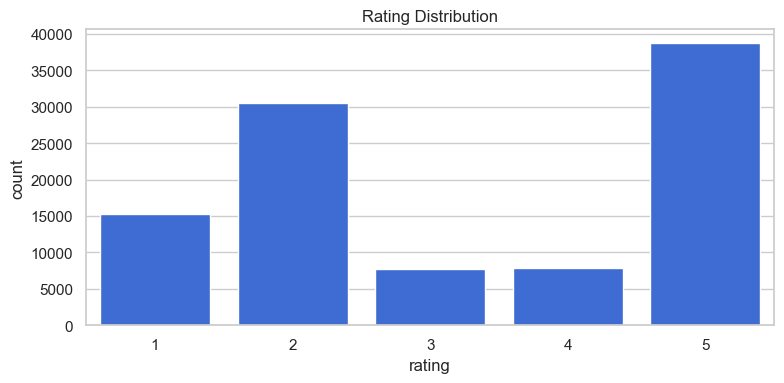

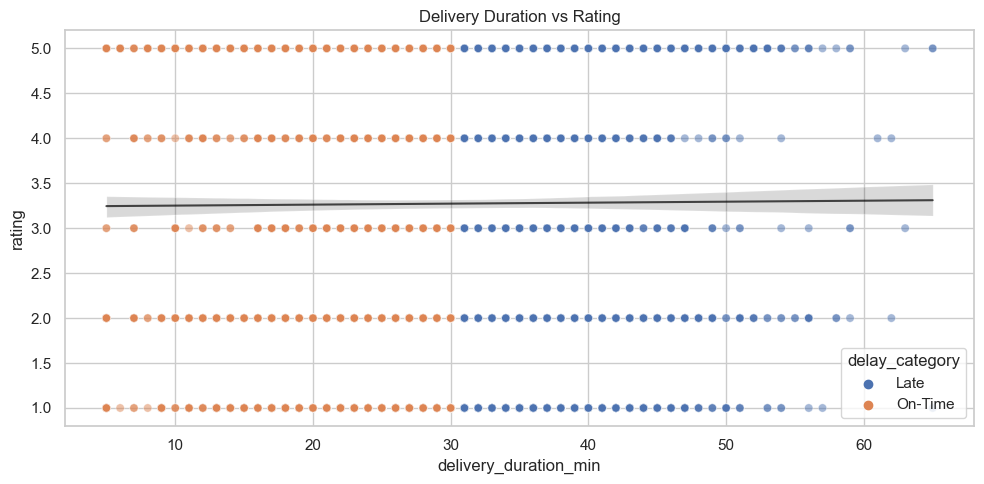

Delay vs rating correlation: 0.0001


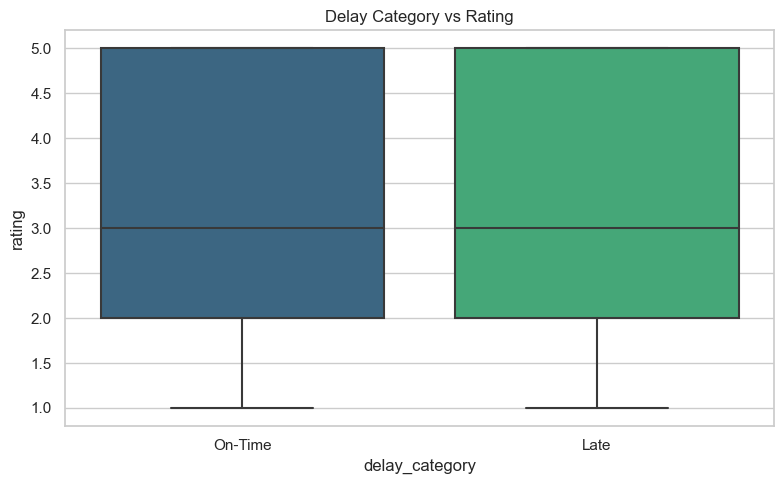

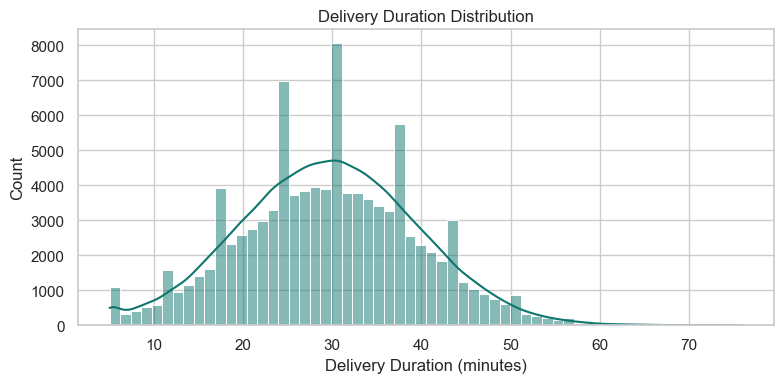

Histogram bins used: 60
Share of deliveries between 20 and 40 min: 70.43%


In [6]:
# Step 7: Visualizations rendered inline only.
if "rating" in cleaned.columns and cleaned["rating"].notna().any():
    # Chart 1: rating frequency distribution.
    plt.figure(figsize=(8, 4))
    sns.countplot(data=cleaned, x="rating", order=sorted(cleaned["rating"].dropna().unique()), color="#2563eb")
    plt.title("Rating Distribution")
    plt.tight_layout()
    plt.show()

    # Chart 2: delivery duration vs rating (sampled for performance on large data).
    sample = cleaned.sample(min(len(cleaned), 5000), random_state=42)
    plt.figure(figsize=(10, 5))
    sns.scatterplot(data=sample, x="delivery_duration_min", y="rating", hue="delay_category", alpha=0.5)
    sns.regplot(
        data=sample,
        x="delivery_duration_min",
        y="rating",
        scatter=False,
        color="black",
        line_kws={"linewidth": 1.5, "alpha": 0.7},
    )
    plt.title("Delivery Duration vs Rating")
    plt.tight_layout()
    plt.show()

    # Quick pattern check: correlation is often small but direction should usually be negative.
    corr_delay_rating = float(cleaned[["delivery_duration_min", "rating"]].corr().iloc[0, 1])
    print(f"Delay vs rating correlation: {corr_delay_rating:.4f}")

    # Chart 3: rating spread by delay category.
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=cleaned, x="delay_category", y="rating", order=["On-Time", "Late"], palette="viridis")
    plt.title("Delay Category vs Rating")
    plt.tight_layout()
    plt.show()
else:
    print("Rating column is missing or empty. Rating-based visualizations are skipped.")

# Chart 4: overall delivery duration distribution with dynamic bins.
duration_values = cleaned["delivery_duration_min"].dropna()
dynamic_bins = int(np.clip(len(np.histogram_bin_edges(duration_values, bins="auto")) - 1, 10, 60)) if not duration_values.empty else 30

plt.figure(figsize=(8, 4))
sns.histplot(duration_values, bins=dynamic_bins, kde=True, color="#0f766e")
plt.title("Delivery Duration Distribution")
plt.xlabel("Delivery Duration (minutes)")
plt.tight_layout()
plt.show()

print(f"Histogram bins used: {dynamic_bins}")
print(f"Share of deliveries between 20 and 40 min: {cleaned['delivery_duration_min'].between(20, 40).mean() * 100:.2f}%")

### Step 7
This section renders inline charts for rating patterns and delivery-duration behavior. Charts are displayed inside the notebook and are not saved to any folder.

### Step 8
This cell adds operational comparison visuals for hour-based delivery performance, platform late-share, and variable correlations to support decision-making.

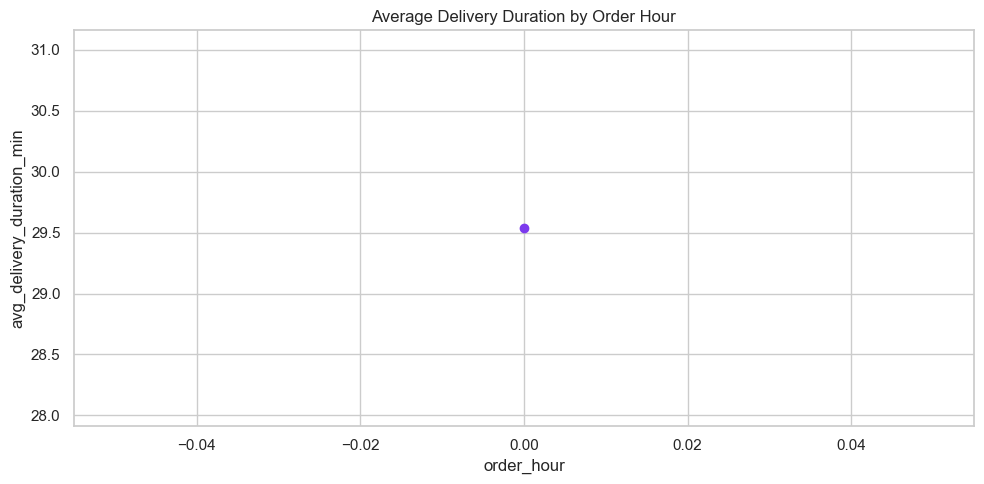

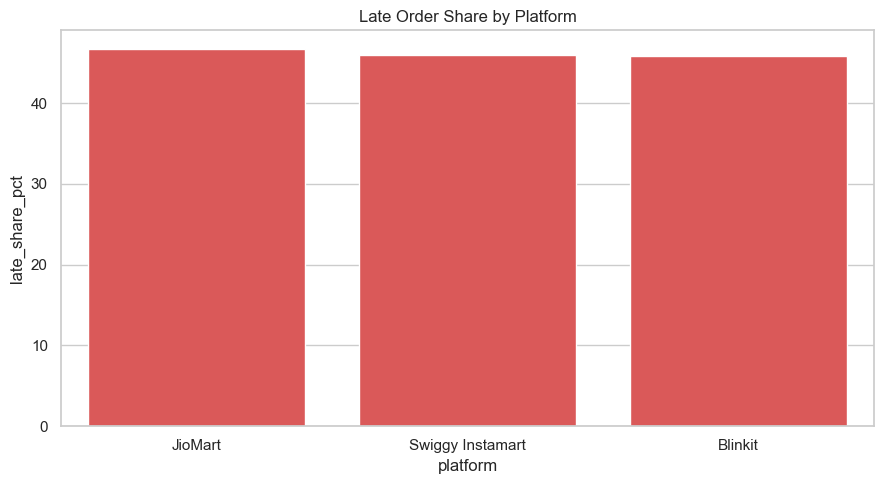

Pie check - percentage sum: 100.00%


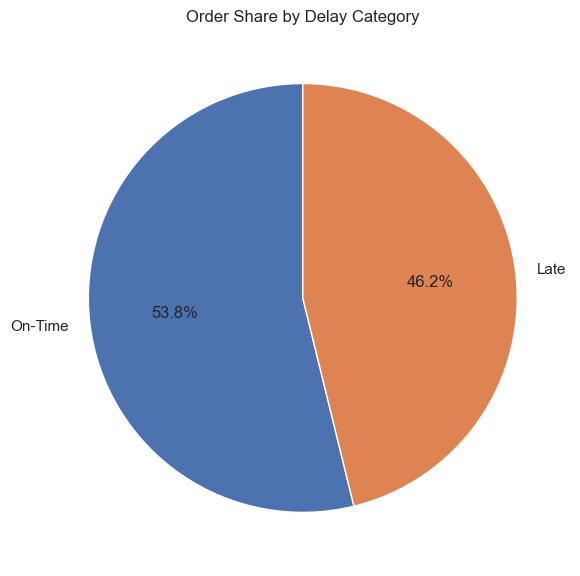

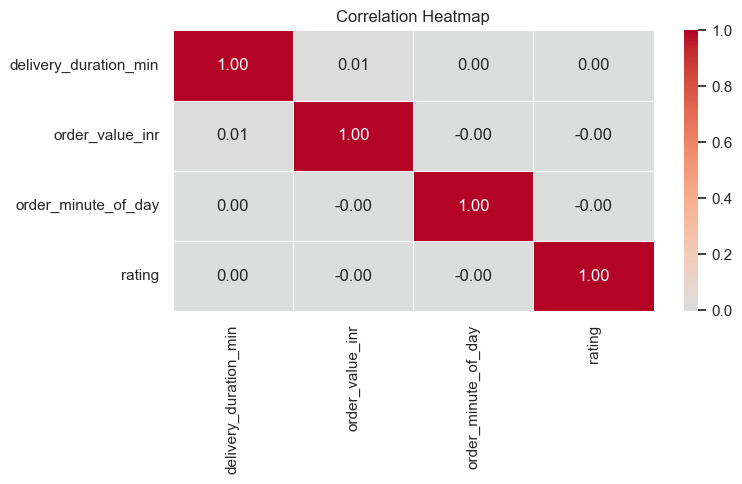

In [7]:
# Step 8: Operational comparison visuals and validation checks.
# Build hour summary from aggregated data only (not raw rows).
hour_summary = cleaned.groupby("order_hour", dropna=True)["delivery_duration_min"].mean().reset_index()
hour_summary["order_hour"] = pd.to_numeric(hour_summary["order_hour"], errors="coerce")
hour_summary["delivery_duration_min"] = pd.to_numeric(hour_summary["delivery_duration_min"], errors="coerce")
hour_summary = hour_summary.dropna().query("0 <= order_hour <= 23").sort_values("order_hour")

# Line chart: average delay by order hour.
plt.figure(figsize=(10, 5))
plt.plot(hour_summary["order_hour"], hour_summary["delivery_duration_min"], marker="o", color="#7c3aed")
plt.title("Average Delivery Duration by Order Hour")
plt.xlabel("order_hour")
plt.ylabel("avg_delivery_duration_min")
plt.tight_layout()
plt.show()

# Platform-level late order share comparison (aggregated mean percentages).
delay_share = (
    cleaned.assign(is_late=cleaned["delay_category"].eq("Late").astype(int))
    .groupby("platform", dropna=False)["is_late"]
    .mean()
    .mul(100)
    .reset_index(name="late_share_pct")
    .sort_values("late_share_pct", ascending=False)
)
plt.figure(figsize=(9, 5))
sns.barplot(data=delay_share, x="platform", y="late_share_pct", color="#ef4444")
plt.title("Late Order Share by Platform")
plt.tight_layout()
plt.show()

# Optional pie chart validation: percentages should sum to 100.
delay_pct = cleaned["delay_category"].value_counts(normalize=True).mul(100)
print(f"Pie check - percentage sum: {delay_pct.sum():.2f}%")
plt.figure(figsize=(6, 6))
plt.pie(delay_pct.values, labels=delay_pct.index, autopct="%1.1f%%", startangle=90)
plt.title("Order Share by Delay Category")
plt.tight_layout()
plt.show()

# Correlation matrix among numeric operational variables only.
corr_cols = ["delivery_duration_min", "order_value_inr", "order_minute_of_day"]
if "rating" in cleaned.columns and cleaned["rating"].notna().any():
    corr_cols.append("rating")
corr = cleaned[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### Step 9
Time-Based Analysis: orders per hour and average delay per hour to identify peak load and peak delay windows.

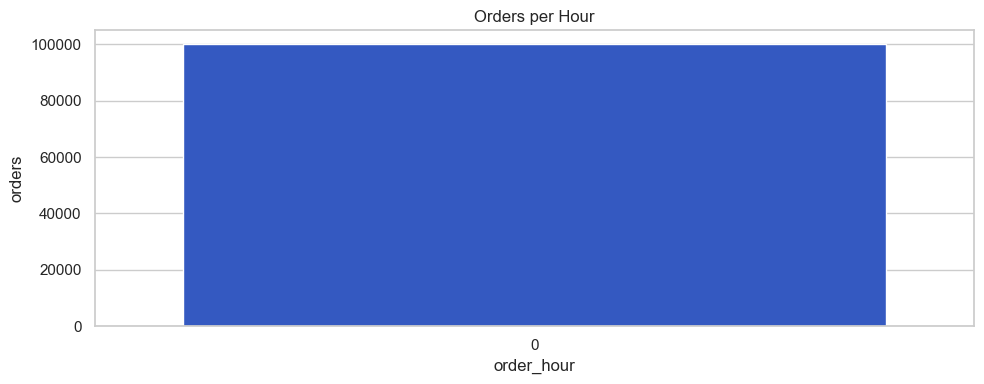

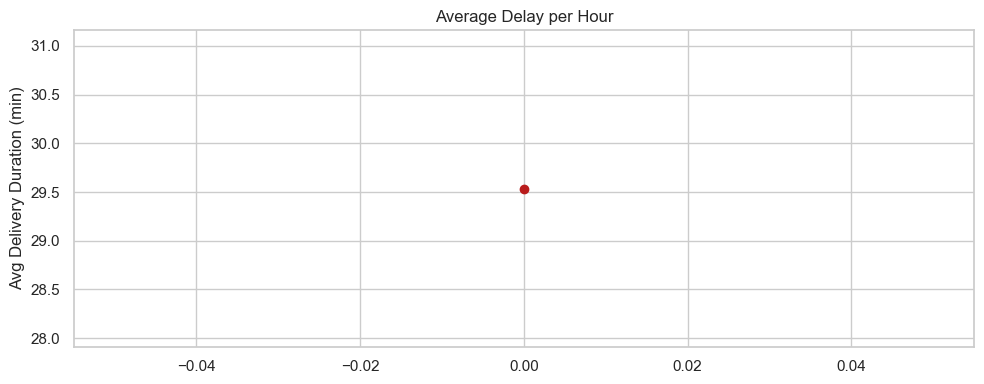

Peak delays happen around 00:00
Note: source order time appears minute-second formatted, so hour-level spread is limited.


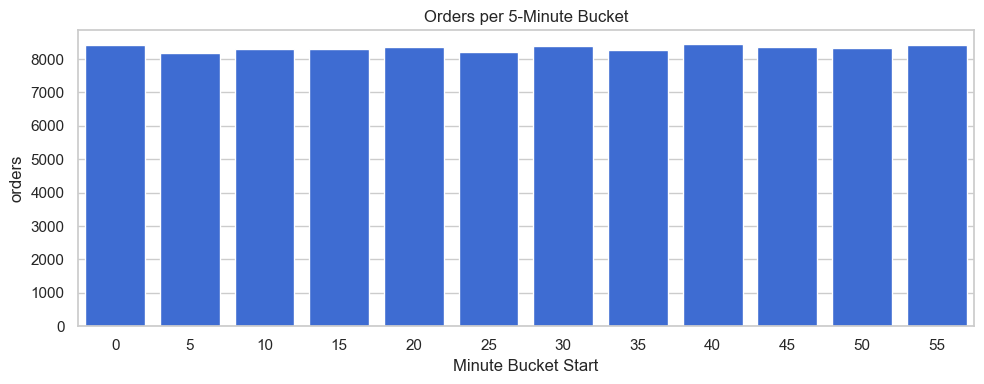

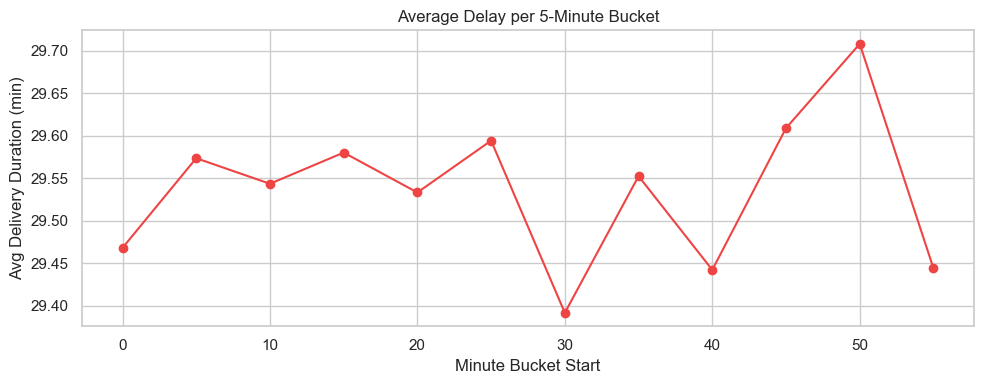

In [8]:
# Aggregate hourly volume and average delay for time-window diagnosis.
hourly_stats = (
    cleaned.groupby("order_hour", dropna=True)
    .agg(
        orders=("order_id", "count"),
        avg_delay_min=("delivery_duration_min", "mean"),
    )
    .dropna()
    .sort_index()
    .reset_index()
)

# Enforce numeric types before plotting.
hourly_stats["order_hour"] = pd.to_numeric(hourly_stats["order_hour"], errors="coerce")
hourly_stats["avg_delay_min"] = pd.to_numeric(hourly_stats["avg_delay_min"], errors="coerce")
hourly_stats = hourly_stats.dropna(subset=["order_hour", "avg_delay_min"])

# Preview hourly summary table.
hourly_stats.head()

# Bar chart: order count by hour.
plt.figure(figsize=(10, 4))
sns.barplot(data=hourly_stats, x="order_hour", y="orders", color="#1d4ed8")
plt.title("Orders per Hour")
plt.tight_layout()
plt.show()

# Line chart: average delay by hour.
plt.figure(figsize=(10, 4))
plt.plot(hourly_stats["order_hour"], hourly_stats["avg_delay_min"], marker="o", color="#b91c1c")
plt.title("Average Delay per Hour")
plt.ylabel("Avg Delivery Duration (min)")
plt.tight_layout()
plt.show()

# Print peak delay hour for quick operational takeaway.
if not hourly_stats.empty:
    peak_hour = int(hourly_stats.loc[hourly_stats["avg_delay_min"].idxmax(), "order_hour"])
    print(f"Peak delays happen around {peak_hour:02d}:00")

# Fallback when hour spread is too limited due source time format.
if hourly_stats["order_hour"].nunique() <= 1 and "order_minute_of_day" in cleaned.columns:
    print("Note: source order time appears minute-second formatted, so hour-level spread is limited.")

    # Use 5-minute buckets as a more informative temporal resolution.
    minute_bucket = (
        cleaned.assign(minute_bucket=(cleaned["order_minute_of_day"] // 5 * 5).astype("Int64"))
        .groupby("minute_bucket", dropna=True)
        .agg(
            orders=("order_id", "count"),
            avg_delay_min=("delivery_duration_min", "mean"),
        )
        .dropna()
        .reset_index()
    )

    plt.figure(figsize=(10, 4))
    sns.barplot(data=minute_bucket, x="minute_bucket", y="orders", color="#2563eb")
    plt.title("Orders per 5-Minute Bucket")
    plt.xlabel("Minute Bucket Start")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(minute_bucket["minute_bucket"], minute_bucket["avg_delay_min"], marker="o", color="#ef4444")
    plt.title("Average Delay per 5-Minute Bucket")
    plt.xlabel("Minute Bucket Start")
    plt.ylabel("Avg Delivery Duration (min)")
    plt.tight_layout()
    plt.show()

### Step 10
Product Category Analysis and Order Value vs Rating analysis for service quality segmentation.

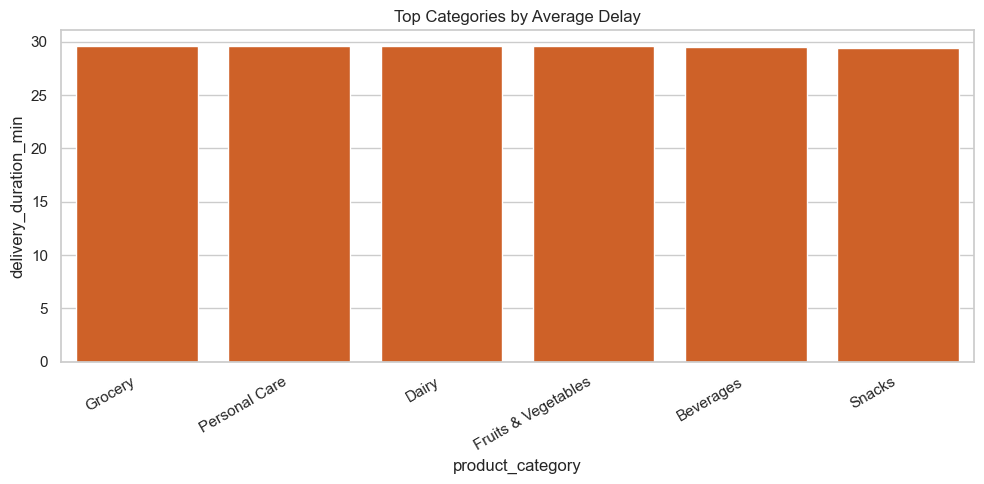

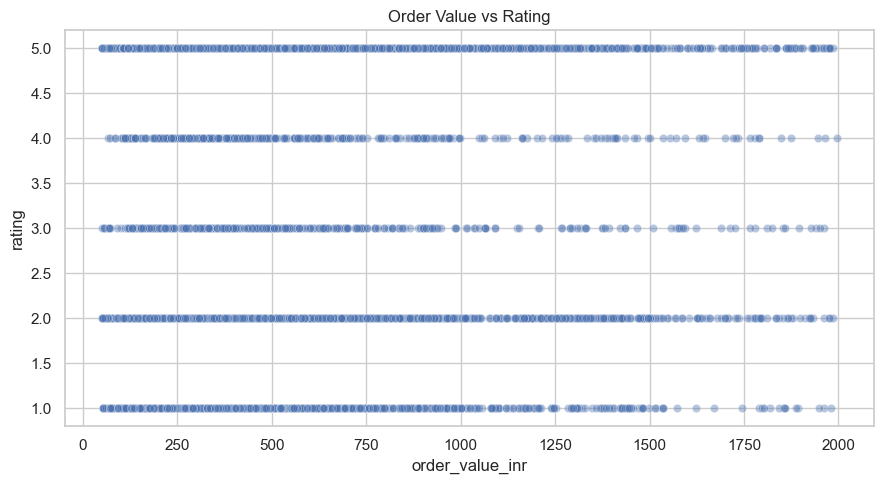

Category with highest delay: Grocery
Category with lowest rating: Grocery


In [9]:
# Compute category-level average delay and rating.
category_stats = (
    cleaned.groupby("product_category", dropna=False)[["delivery_duration_min", "rating"]]
    .mean()
    .sort_values("delivery_duration_min", ascending=False)
)
category_stats.head(10)

# Chart: categories with highest average delay.
plt.figure(figsize=(10, 5))
sns.barplot(
    data=category_stats.reset_index().head(10),
    x="product_category",
    y="delivery_duration_min",
    color="#ea580c",
)
plt.title("Top Categories by Average Delay")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Chart: order value vs rating relationship (sampled to keep plotting fast).
plt.figure(figsize=(9, 5))
sns.scatterplot(x="order_value_inr", y="rating", data=cleaned.sample(min(5000, len(cleaned)), random_state=42), alpha=0.4)
plt.title("Order Value vs Rating")
plt.tight_layout()
plt.show()

# Print key category insights for quick interpretation.
print("Category with highest delay:", category_stats["delivery_duration_min"].idxmax())
print("Category with lowest rating:", category_stats["rating"].idxmin())

### Step 11
Refund Analysis extension: compare refund behavior across rating, delay category, and duration bands.

Refund rate overall (%): 45.82

Average rating by refund status:
refund_requested
No     4.571861
Yes    1.666798
Name: rating, dtype: float64

Refund rate by delay category (%):
delay_category
Late       45.941731
On-Time    45.713755
Name: refund_yes, dtype: float64

Late orders have 1.00x higher refund rate than On-Time orders


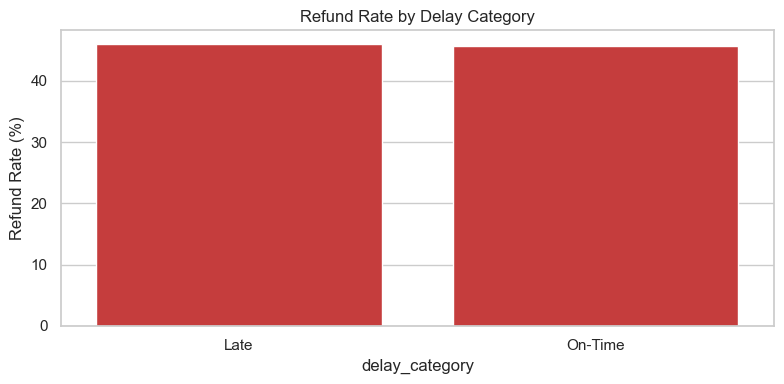

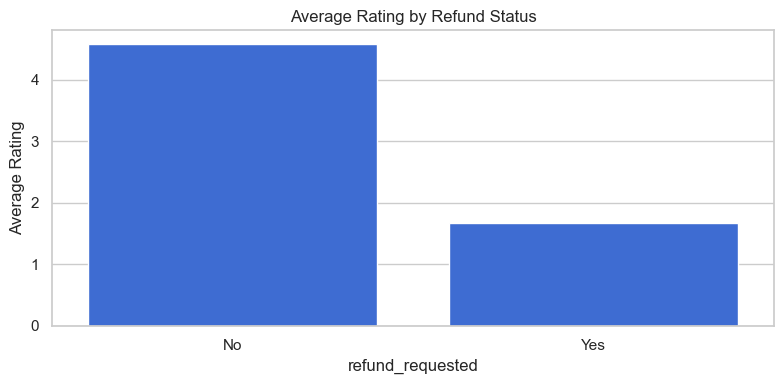

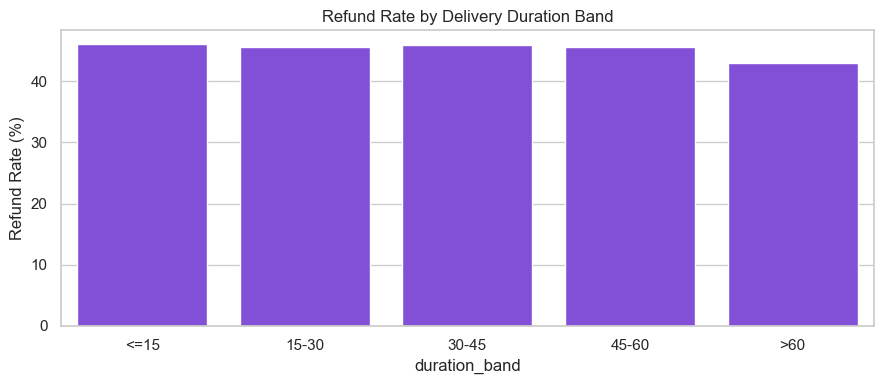

In [10]:
# Step 11: Refund analysis extensions.
refund_df = cleaned.copy()
refund_df["refund_yes"] = refund_df["refund_requested"].eq("Yes").astype(int)

print("Refund rate overall (%):", round(refund_df["refund_yes"].mean() * 100, 2))

# Average rating split by refund status.
refund_vs_rating = refund_df.groupby("refund_requested")["rating"].mean()
print("\nAverage rating by refund status:")
print(refund_vs_rating)

# Refund rate split by delay category.
refund_vs_delay = (
    refund_df.groupby("delay_category")["refund_yes"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)
print("\nRefund rate by delay category (%):")
print(refund_vs_delay)

if "Late" in refund_vs_delay.index and "On-Time" in refund_vs_delay.index and refund_vs_delay["On-Time"] > 0:
    print(f"\nLate orders have {refund_vs_delay['Late']/refund_vs_delay['On-Time']:.2f}x higher refund rate than On-Time orders")

# Refund rate by delivery duration band.
refund_df["duration_band"] = pd.cut(
    refund_df["delivery_duration_min"],
    bins=[-np.inf, 15, 30, 45, 60, np.inf],
    labels=["<=15", "15-30", "30-45", "45-60", ">60"],
)
refund_by_band = (
    refund_df.groupby("duration_band", dropna=False)["refund_yes"]
    .mean()
    .mul(100)
    .reset_index(name="refund_rate_pct")
)

# Visual 1: refund rates by delay segment.
plt.figure(figsize=(8, 4))
sns.barplot(x=refund_vs_delay.index, y=refund_vs_delay.values, color="#dc2626")
plt.title("Refund Rate by Delay Category")
plt.ylabel("Refund Rate (%)")
plt.tight_layout()
plt.show()

# Visual 2: average rating by refund status.
plt.figure(figsize=(8, 4))
sns.barplot(x=refund_vs_rating.index, y=refund_vs_rating.values, color="#2563eb")
plt.title("Average Rating by Refund Status")
plt.ylabel("Average Rating")
plt.tight_layout()
plt.show()

# Visual 3: refund rate by duration band.
plt.figure(figsize=(9, 4))
sns.barplot(data=refund_by_band, x="duration_band", y="refund_rate_pct", color="#7c3aed")
plt.title("Refund Rate by Delivery Duration Band")
plt.ylabel("Refund Rate (%)")
plt.tight_layout()
plt.show()

### Step 12
Simple ML Model: baseline linear regression to predict rating using delivery duration.

In [11]:
# Import baseline regression model and evaluation utilities.
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Use delivery duration as a simple single-feature predictor for rating.
ml_df = cleaned[["delivery_duration_min", "rating"]].dropna()
X = ml_df[["delivery_duration_min"]]
y = ml_df["rating"]

# Split data into training and testing sets for unbiased evaluation.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train linear model and generate predictions.
model = LinearRegression()
model.fit(X_train, y_train)
preds = model.predict(X_test)

# Report baseline performance and coefficient interpretation.
print("LinearRegression baseline")
print("MAE:", round(mean_absolute_error(y_test, preds), 4))
print("R2:", round(r2_score(y_test, preds), 4))
print("Coefficient (rating change per +1 min delay):", round(float(model.coef_[0]), 4))

LinearRegression baseline
MAE: 1.4842
R2: -0.0001
Coefficient (rating change per +1 min delay): -0.0003


### Step 13
Business Recommendations:
- If delivery is expected to exceed 30 minutes, automatically send apology coupon communication.
- Prioritize high-delay product categories for operational fixes.
- Increase delivery partner availability during peak delay hours.
- Trigger fast support and retention workflows for high refund-risk segments.
- Use model predictions as an early warning for customer satisfaction drops.